In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx

from dataset import create_toy_multifurcating_data
import torch

Loaded toy multifurcating dataset with 1000 cells


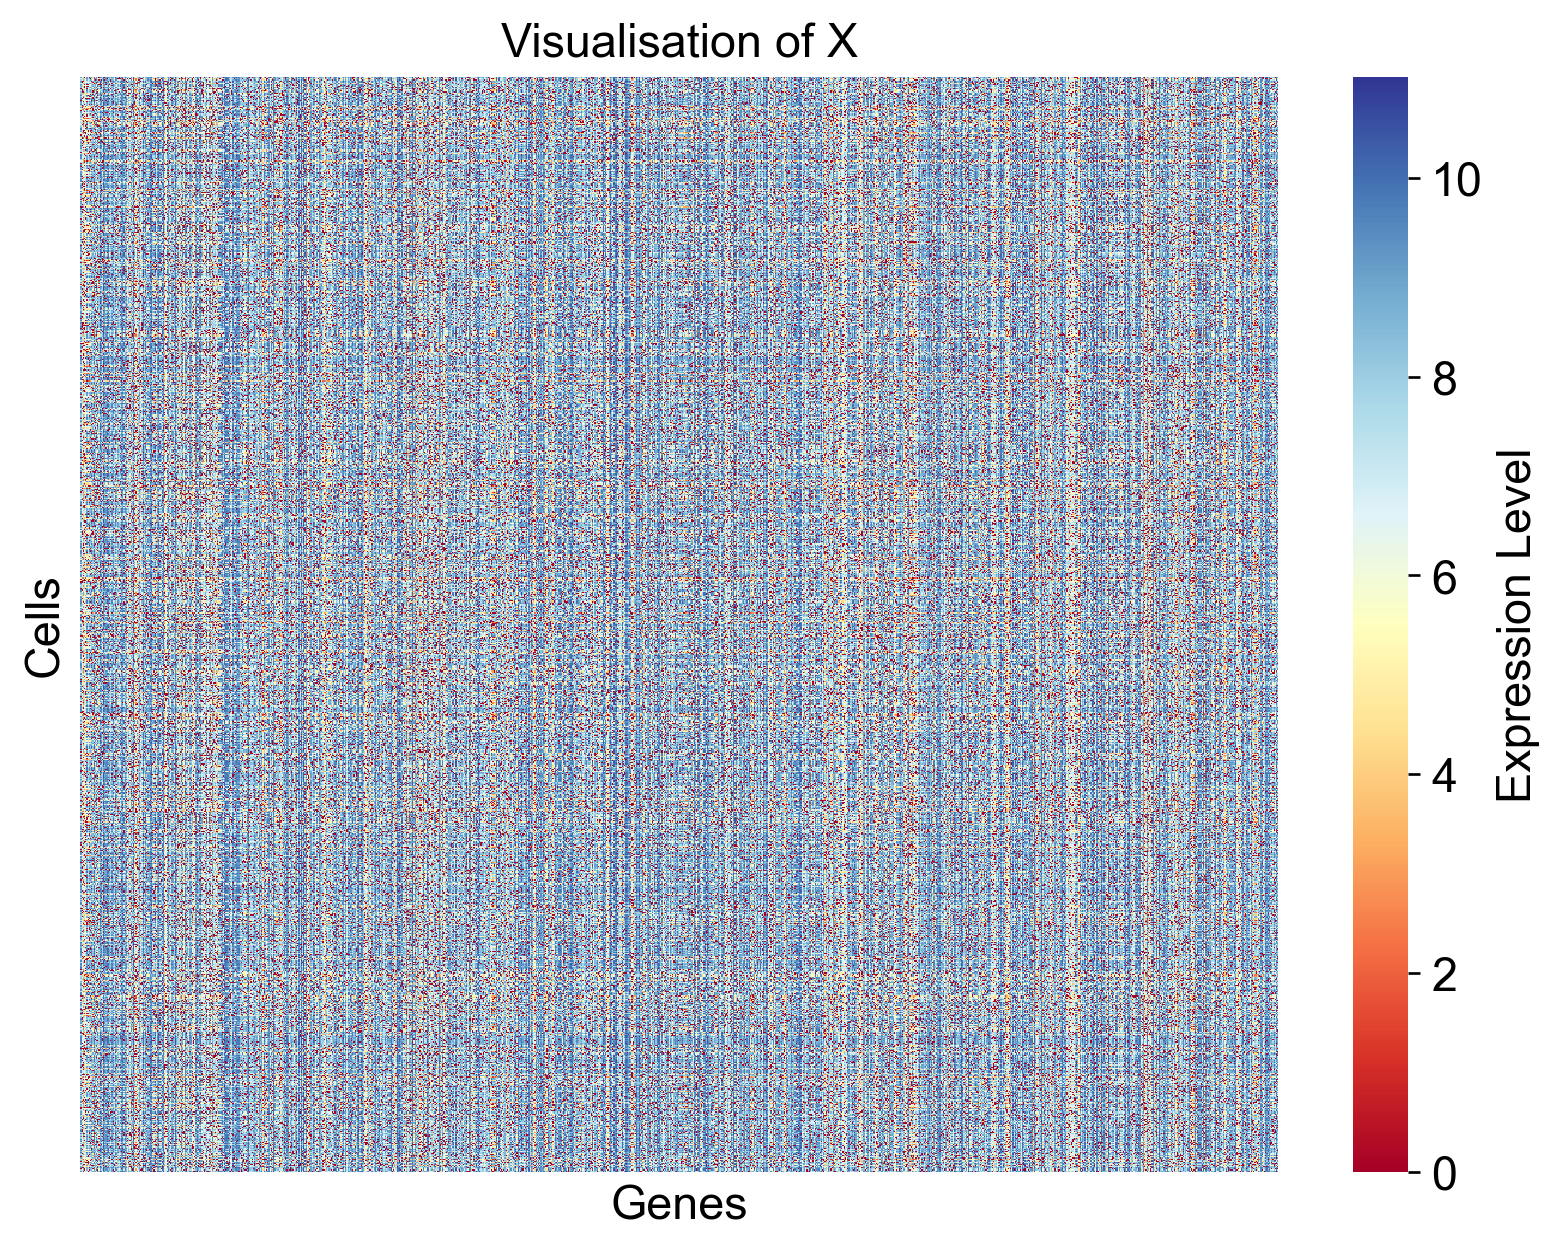

In [4]:

adata_subsampled, x, adj = create_toy_multifurcating_data()
# Create heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(x, cmap="RdYlBu")  # returns the Axes object
cbar = ax.collections[0].colorbar  # access the colorbar
cbar.set_label('Expression Level')  # set the label
plt.title("Visualisation of X")
plt.xlabel("Genes")
plt.ylabel("Cells")

# Remove tick labels
ax.set_xticks([])  # remove x-axis numbers (genes)
ax.set_yticks([])  # remove y-axis numbers (cells)

plt.show()

In [15]:
G = nx.from_numpy_array(adj.numpy())
pos = nx.spring_layout(G, seed=42, iterations=200, k=10)
x_original = np.zeros((len(pos), 2))
for i, coord in pos.items():
    x_original[i] = coord


x_original = torch.tensor(x_original, dtype=torch.float32)

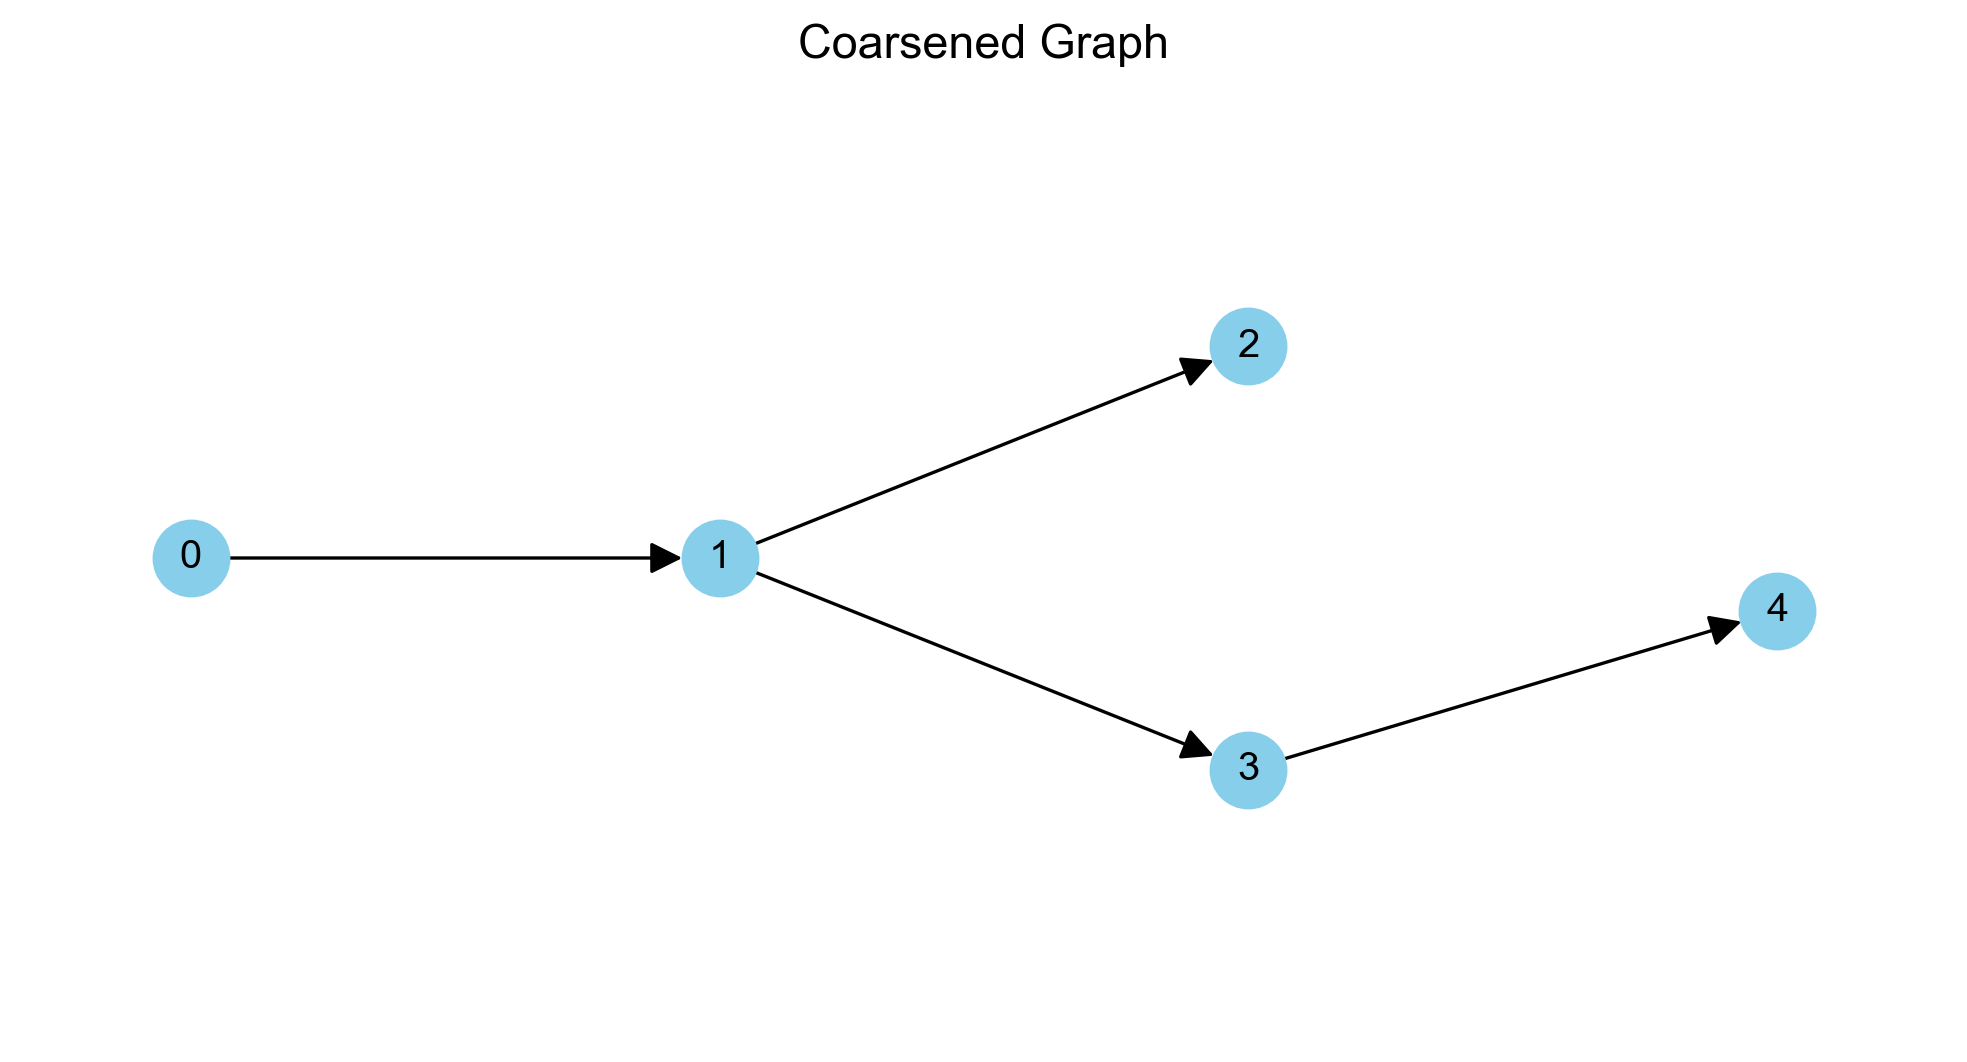

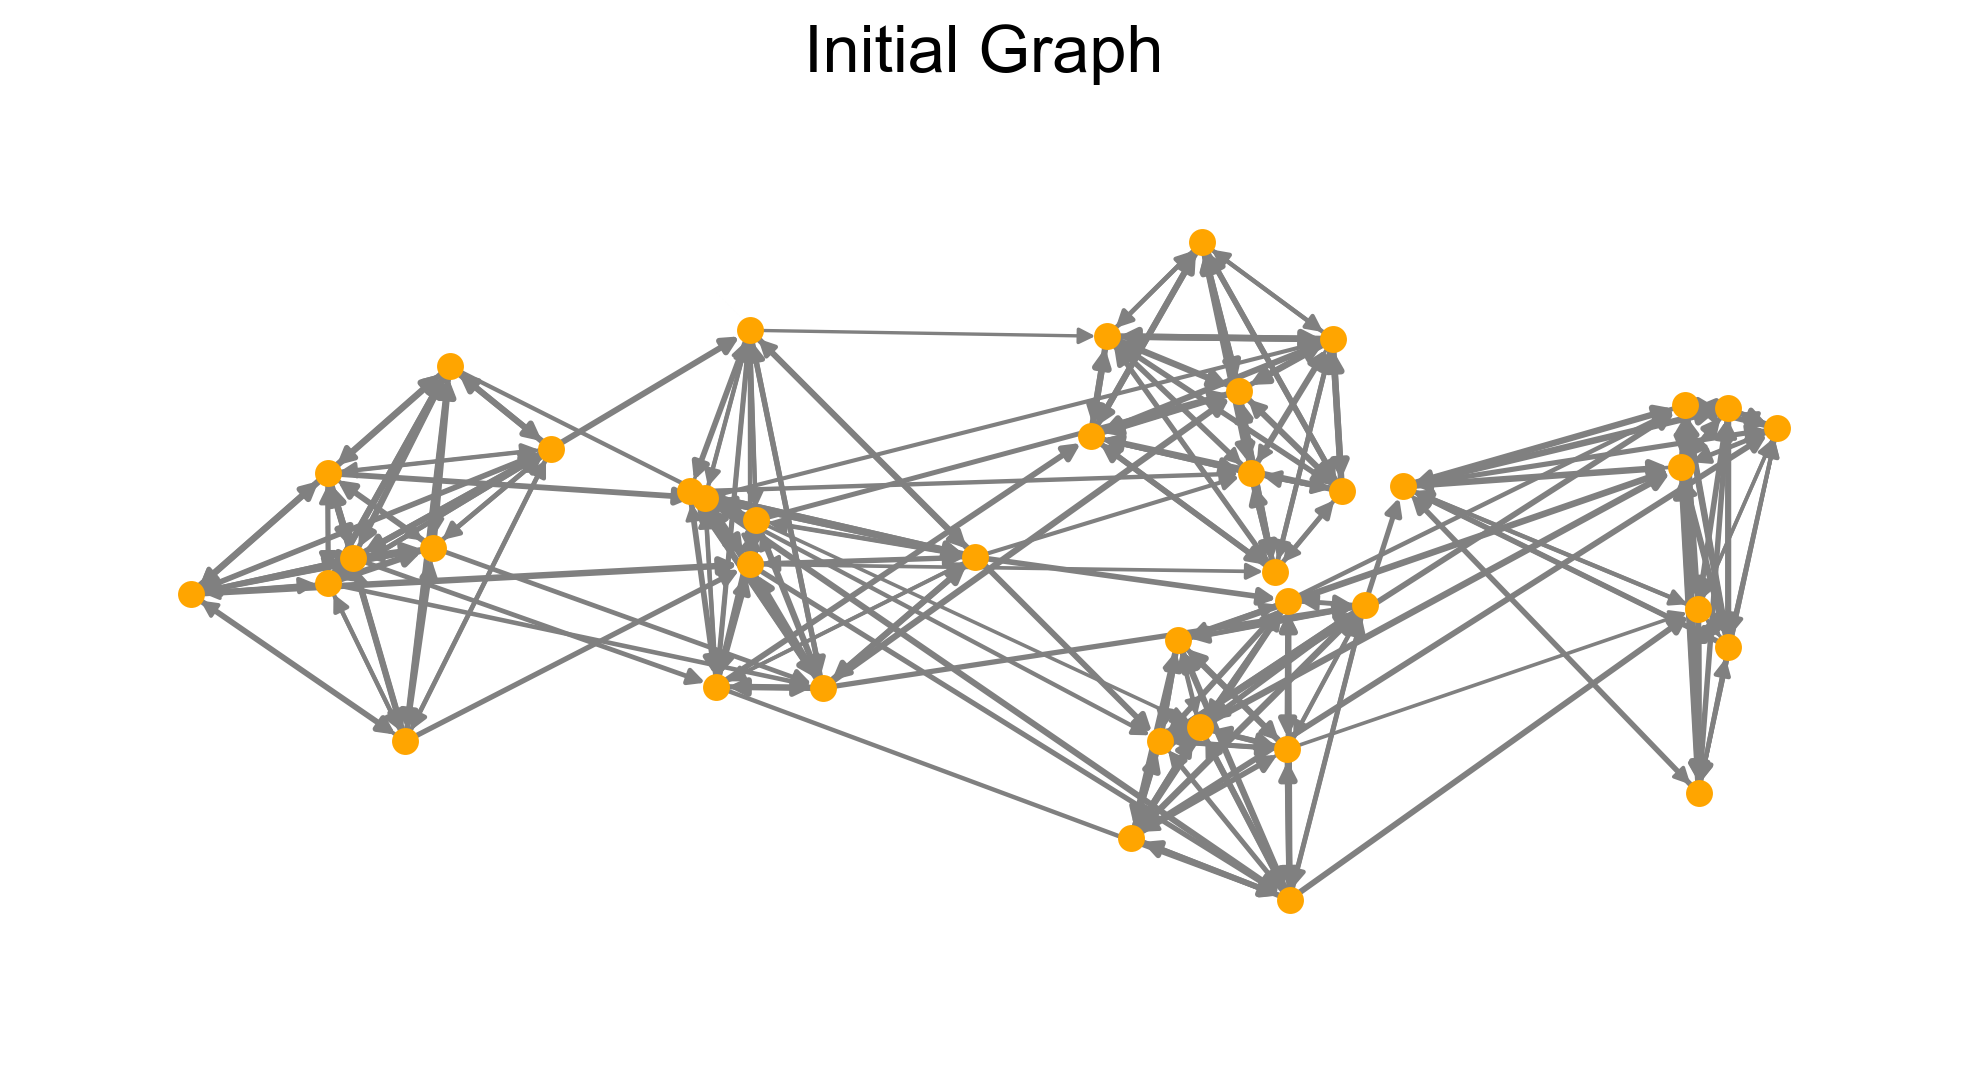

In [55]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Small branching network (unchanged)
# -----------------------------
small_G = nx.DiGraph()
edges_small = [(0,1), (1,2), (1,3), (3,4)]
small_G.add_edges_from(edges_small)

pos_small = {
    0: (0,0),
    1: (2,0),
    2: (4, 0.8),
    3: (4, -0.8),
    4: (6, -0.2)
}

plt.figure(figsize=(8,4))
nx.draw(small_G, pos_small, with_labels=True, node_color='skyblue', node_size=500, arrowsize=20)
plt.title("Coarsened Graph")
plt.axis('equal')
plt.show()

# -----------------------------
# Step 2: Large network with clusters closer together
# -----------------------------
large_G = nx.DiGraph()
large_pos = {}

np.random.seed(42)
nodes_per_small_node = 8
node_idx = 0

# Scale down cluster spacing by a factor (e.g., 0.6)
cluster_scale = 0.1

for small_node, center in pos_small.items():
    center = np.array(center) * cluster_scale  # move cluster closer to origin
    for i in range(nodes_per_small_node):
        jitter = np.random.randn(2) * 0.05  # smaller jitter
        large_pos[node_idx] = center + jitter
        node_idx += 1

num_large_nodes = node_idx

# Intra-cluster edges
for small_node, start_idx in zip(pos_small.keys(), range(0, num_large_nodes, nodes_per_small_node)):
    cluster_nodes = range(start_idx, start_idx + nodes_per_small_node)
    for i in cluster_nodes:
        for j in cluster_nodes:
            if i != j:
                large_G.add_edge(i,j,weight=np.random.rand()*0.5+0.5)

# Inter-cluster edges (preserve trajectory)
for u,v in edges_small:
    start_cluster = range(u*nodes_per_small_node, (u+1)*nodes_per_small_node)
    end_cluster = range(v*nodes_per_small_node, (v+1)*nodes_per_small_node)
    for i in start_cluster:
        j = np.random.choice(end_cluster)
        large_G.add_edge(i,j,weight=np.random.rand()*0.5+0.5)

# Plot large network
plt.figure(figsize=(8,4))
weights = [large_G[u][v]['weight'] for u,v in large_G.edges()]
nx.draw(large_G, pos=large_pos, node_size=50, node_color='orange', arrowsize=10, edge_color='gray', width=[w*2 for w in weights])
plt.title("Initial Graph", fontsize=20)
plt.axis('equal')
plt.show()


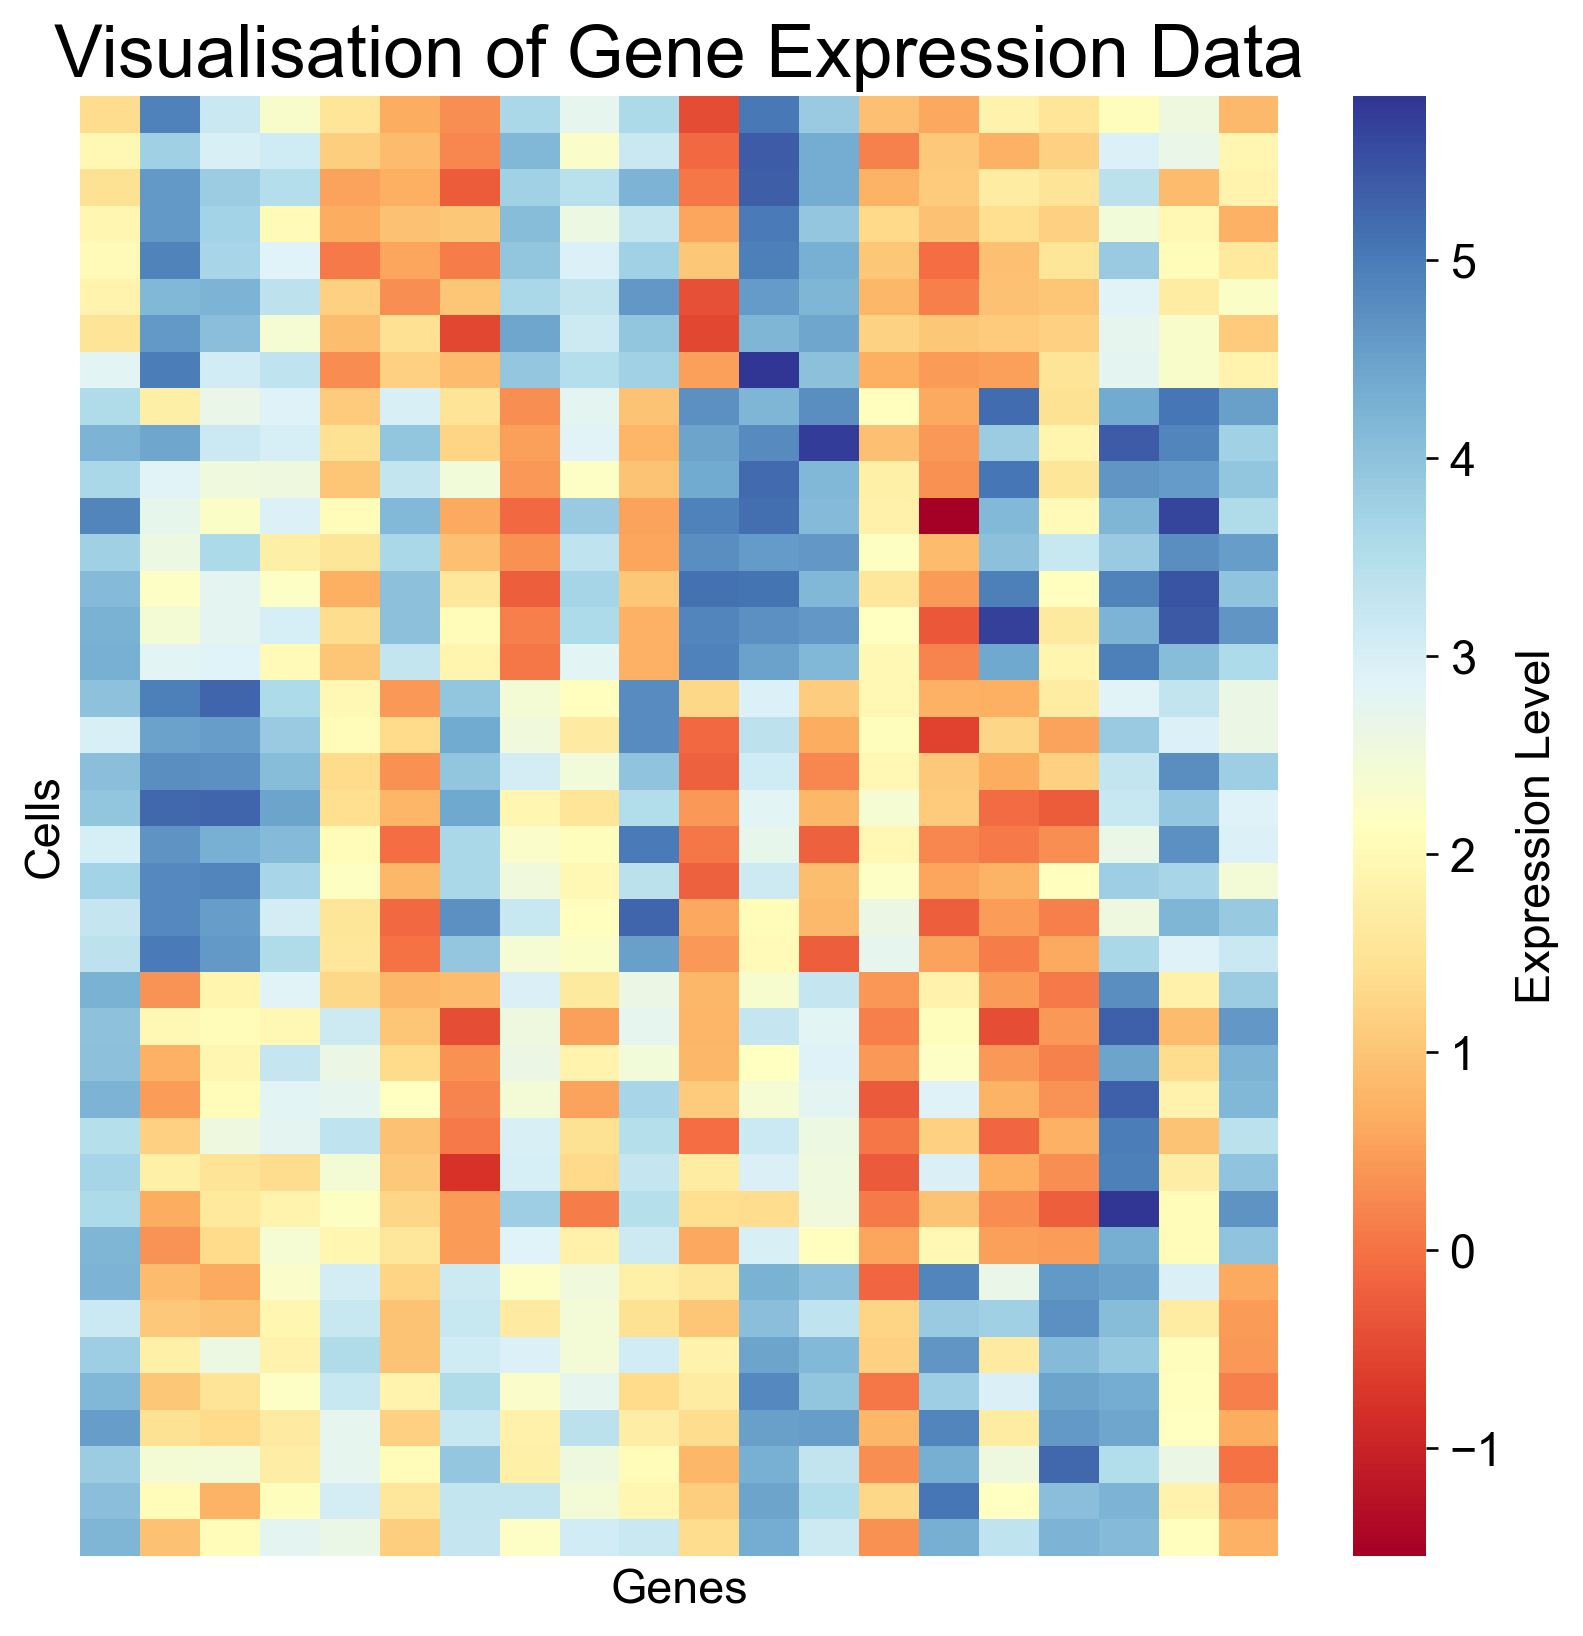

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# Parameters
# -----------------------------
num_clusters = 5      # 5 clusters
nodes_per_cluster = 8 # e.g., from the previous "large network" example
num_nodes = num_clusters * nodes_per_cluster
num_genes = 20        # number of genes

# -----------------------------
# Step 1: Generate feature matrix
# -----------------------------
np.random.seed(42)
X = np.zeros((num_nodes, num_genes))

for cluster in range(num_clusters):
    # Each cluster has a base expression pattern
    cluster_center = np.random.rand(num_genes) * 5
    start = cluster * nodes_per_cluster
    end = start + nodes_per_cluster
    # Nodes in cluster = cluster_center + small noise
    X[start:end, :] = cluster_center + np.random.randn(nodes_per_cluster, num_genes) * 0.5

# -----------------------------
# Step 2: Plot heatmap
# -----------------------------
plt.figure(figsize=(8, 8))

# Use a red-yellow-blue colormap

ax = sns.heatmap(X, cmap="RdYlBu")  # returns the Axes object
cbar = ax.collections[0].colorbar  # access the colorbar
cbar.set_label('Expression Level')  # set the label
plt.title("Gene Expression Heatmap")
plt.title("Visualisation of Gene Expression Data", fontsize=22)
plt.xlabel("Genes")
plt.ylabel("Cells")

# Remove tick labels
ax.set_xticks([])  # remove x-axis numbers (genes)
ax.set_yticks([])  # remove y-axis numbers (cells)
plt.show()


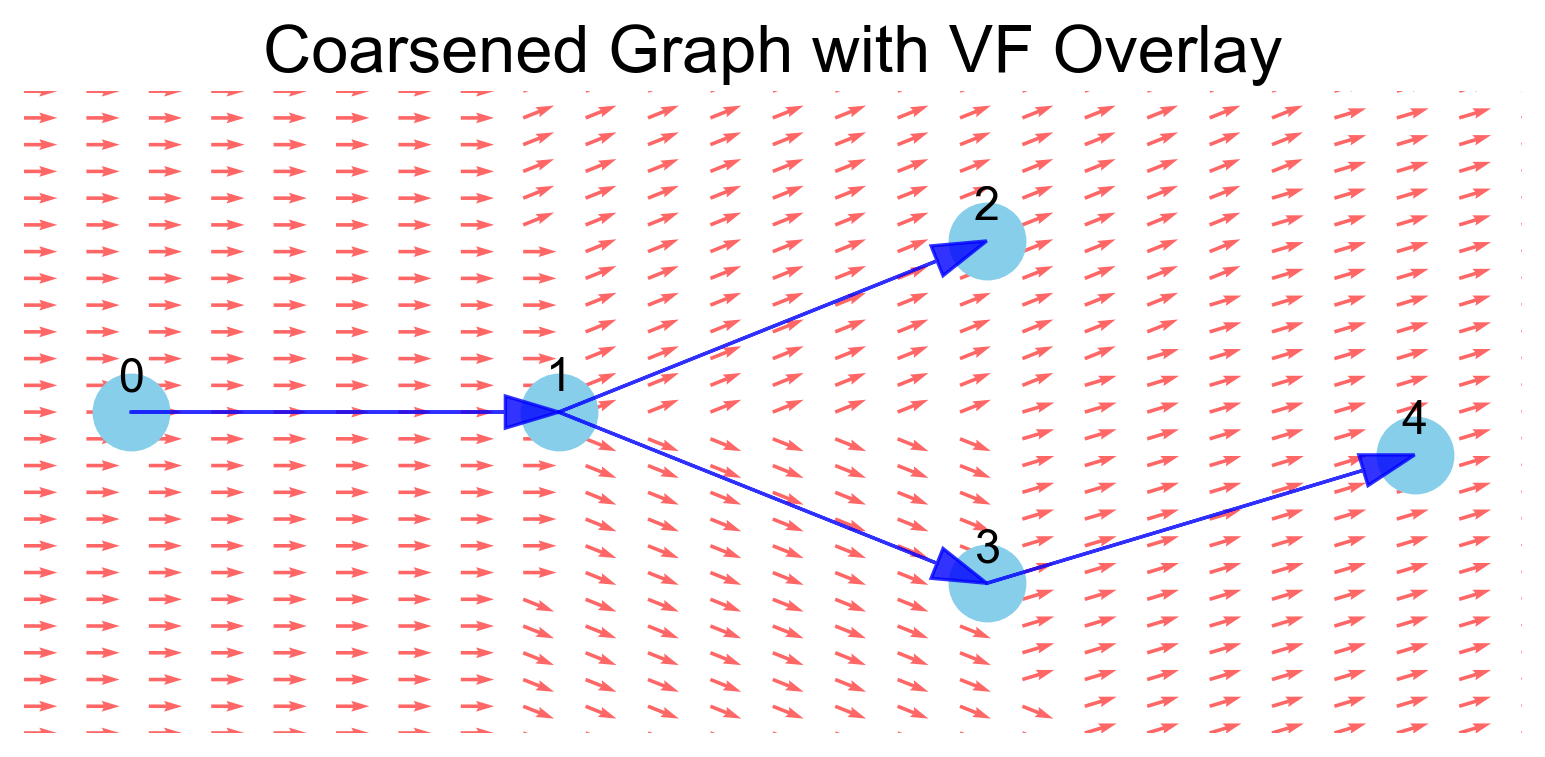

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Graph positions
pos_small = {
    0: np.array([0,0]),
    1: np.array([2,0]),
    2: np.array([4, 0.8]),
    3: np.array([4, -0.8]),
    4: np.array([6, -0.2])
}

edges_small = [(0,1), (1,2), (1,3), (3,4)]

# Grid
x_min, x_max = -0.5, 6.5
y_min, y_max = -1.5, 1.5
grid_x, grid_y = np.meshgrid(np.linspace(x_min, x_max, 25),
                             np.linspace(y_min, y_max, 25))
U = np.zeros_like(grid_x)
V = np.zeros_like(grid_y)

# Function to compute distance from point to segment
def point_to_segment(p, a, b):
    ap = p - a
    ab = b - a
    t = np.clip(np.dot(ap, ab)/np.dot(ab, ab), 0, 1)
    closest = a + t * ab
    return np.linalg.norm(p - closest), (b - a)

# Compute vectors
for i in range(grid_x.shape[0]):
    for j in range(grid_x.shape[1]):
        p = np.array([grid_x[i,j], grid_y[i,j]])
        min_dist = np.inf
        vec = np.array([0.0, 0.0])
        for u, v in edges_small:
            a, b = pos_small[u], pos_small[v]
            dist, edge_vec = point_to_segment(p, a, b)
            if dist < min_dist:
                min_dist = dist
                vec = edge_vec
        vec = vec / (np.linalg.norm(vec)+1e-6)
        U[i,j], V[i,j] = vec

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,8))

# Vector field
plt.quiver(grid_x, grid_y, U, V, color='red', alpha=0.6)

# Overlay graph nodes
for n, coord in pos_small.items():
    plt.scatter(*coord, color='skyblue', s=500)
    plt.text(coord[0], coord[1]+0.1, str(n), ha='center')

# Overlay trajectory arrows (edges)
for u, v in edges_small:
    src = pos_small[u]
    tgt = pos_small[v]
    vec = tgt - src
    plt.arrow(src[0], src[1], vec[0], vec[1],
              head_width=0.15, head_length=0.25, fc='blue', ec='blue', alpha=0.8, length_includes_head=True)

# Remove axes and grid
plt.axis('off')
plt.title("Coarsened Graph with VF Overlay", fontsize=20)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal')
plt.show()
